
===== DISTANCIAS ENTRE VALLES =====

Datos 1:
[19.  16.9]
Promedio = 17.95 +_- 1.05V

Datos 2:
[18.2 20.2]
Promedio = 19.20 +_- 1.00V

===== DISTANCIAS ENTRE PICOS =====

Datos 1:
[18.5 20.5]
Promedio = 19.50 +_- 1.00V

Datos 2:
[15.9 20.9]
Promedio = 18.40 +_- 2.50V


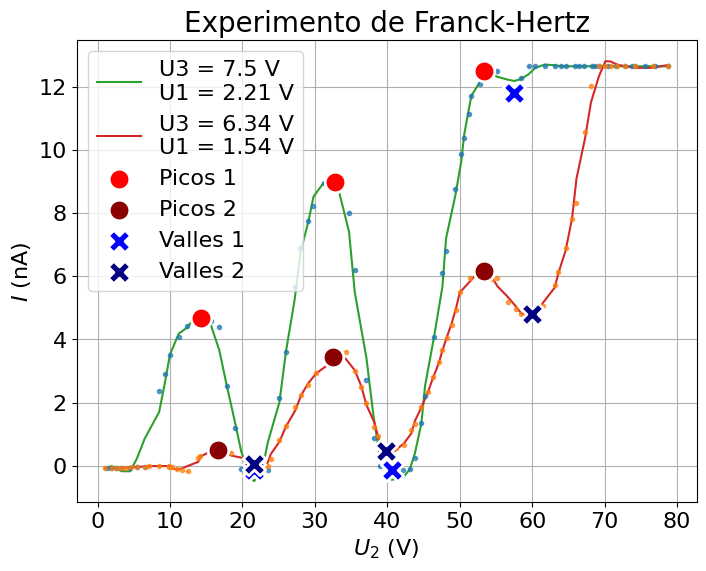

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from scipy.signal import savgol_filter, find_peaks


# =========================================================
# FUNCIÓN PARA ENCONTRAR PICOS
# =========================================================

def encontrar_picos(y,
                    suavizado=9,
                    orden=3,
                    prominencia=0.15,
                    distancia=6):

    y = np.array(y)

    # suavizado
    y_suave = savgol_filter(y, suavizado, orden)

    # detección de picos
    picos, propiedades = find_peaks(
        y_suave,
        prominence=prominencia,
        distance=distancia
    )

    return picos, y_suave

# =========================================================
# CARGAR DATOS
# =========================================================

data_1 = read_csv('Data_01.csv')
data_2 = read_csv('Data_02.csv')

# Corrección de signo
data_1.loc[data_1['ua'] < 0.2, 'ua'] *= -1
data_2.loc[data_2['ua'] < 0.2, 'ua'] *= -1

# Variables
ua1 = data_1['ua']
ua2 = data_2['ua']

u2_1 = data_1['u2']
u2_2 = data_2['u2']

# =========================================================
# ENCONTRAR PICOS
# =========================================================
picos_1, suave_1 = encontrar_picos(
    ua1,
    prominencia=0.25,
    distancia=5
)

picos_2, suave_2 = encontrar_picos(
    ua2,
    prominencia=0.25,
    distancia=5
)

valles_1, _ = encontrar_picos(
    -ua1,
    prominencia=0.25,
    distancia=5
)

valles_2, _ = encontrar_picos(
    -ua2,
    prominencia=0.25,
    distancia=5
)


distancias_1v = np.diff(u2_1.iloc[valles_1])
distancias_2v = np.diff(u2_2.iloc[valles_2])
distancias_1p = np.diff(u2_1.iloc[picos_1])
distancias_2p = np.diff(u2_2.iloc[picos_2])
print('\n===== DISTANCIAS ENTRE VALLES =====')

print('\nDatos 1:')
print(distancias_1v)
print(f'Promedio = {np.mean(distancias_1v):.2f} +_- {np.std(distancias_1v):.2f}V')

print('\nDatos 2:')
print(distancias_2v)
print(f'Promedio = {np.mean(distancias_2v):.2f} +_- {np.std(distancias_2v):.2f}V')

print('\n===== DISTANCIAS ENTRE PICOS =====')

print('\nDatos 1:')
print(distancias_1p)
print(f'Promedio = {np.mean(distancias_1p):.2f} +_- {np.std(distancias_1p):.2f}V')

print('\nDatos 2:')
print(distancias_2p)
print(f'Promedio = {np.mean(distancias_2p):.2f} +_- {np.std(distancias_2p):.2f}V')

# =========================================================
# GRÁFICA
# =========================================================

plt.figure(figsize=(8,6))

# Barras de error
error = 0.01   # ajustar según resolución del equipo

plt.errorbar(
    u2_1,
    ua1,
    yerr=error,
    fmt='.',
    alpha=0.7
)

plt.errorbar(
    u2_2,
    ua2,
    yerr=error,
    fmt='.',
    alpha=0.7
)

# Curvas suavizadas
plt.plot(
    u2_1,
    suave_1,
    label='U3 = 7.5 V\nU1 = 2.21 ' \
    'V'
)

plt.plot(
    u2_2,
    suave_2,
    label='U3 = 6.34 V\nU1 = 1.54 V'
)

# =========================================================
# PICOS
# =========================================================

plt.scatter(
    u2_1.iloc[picos_1],
    ua1.iloc[picos_1],
    s=220,
    label='Picos 1',
    color='red',
    edgecolors='white',
    linewidths=2,
    marker='o',
    zorder=10
)

plt.scatter(
    u2_2.iloc[picos_2],
    ua2.iloc[picos_2],
    s=220,
    label='Picos 2',
    color='darkred',
    edgecolors='white',
    linewidths=2,
    marker='o',
    zorder=10
)

# =========================================================
# VALLES
# =========================================================

plt.scatter(
    u2_1.iloc[valles_1],
    ua1.iloc[valles_1],
    s=260,
    label='Valles 1',
    color='blue',
    edgecolors='white',
    linewidths=2,
    marker='X',
    zorder=11
)

plt.scatter(
    u2_2.iloc[valles_2],
    ua2.iloc[valles_2],
    s=260,
    label='Valles 2',
    color='navy',
    edgecolors='white',
    linewidths=2,
    marker='X',
    zorder=11
)

# =========================================================
# ESTILO
# =========================================================

plt.title('Experimento de Franck-Hertz', fontsize=20)

plt.xlabel(r'$U_2$ (V)', fontsize=16)
plt.ylabel(r'$I$ (nA)', fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid()
plt.legend(fontsize = 16)

plt.savefig('Experimento_Franck_Hertz.png',            bbox_inches='tight',
            dpi=300)
plt.show()